In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [5]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [6]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
print(df.shape)

df.info()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


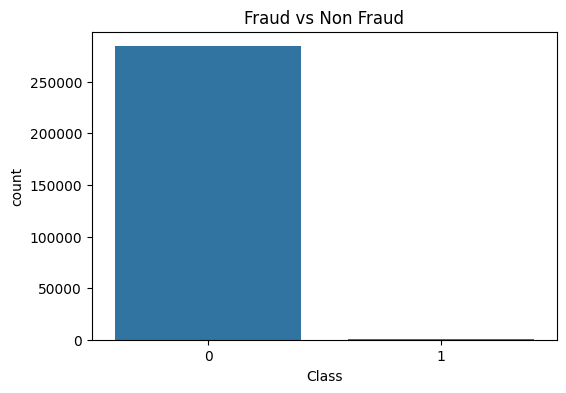

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Non Fraud")

plt.show()

In [11]:
fraud_percent = (
    df['Class'].value_counts(normalize=True)*100
)

print(fraud_percent)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


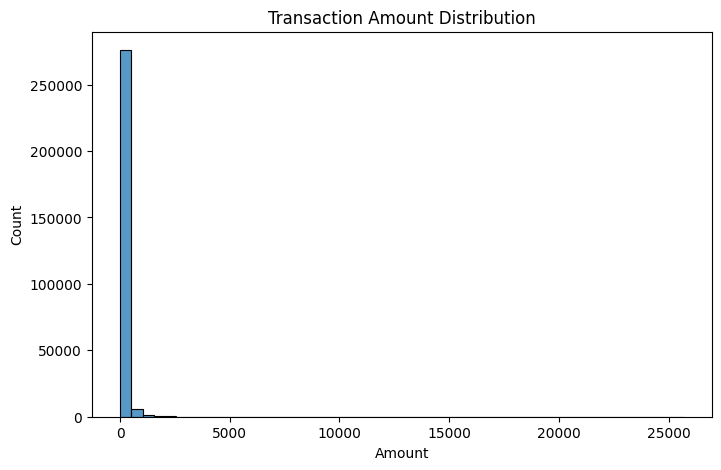

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

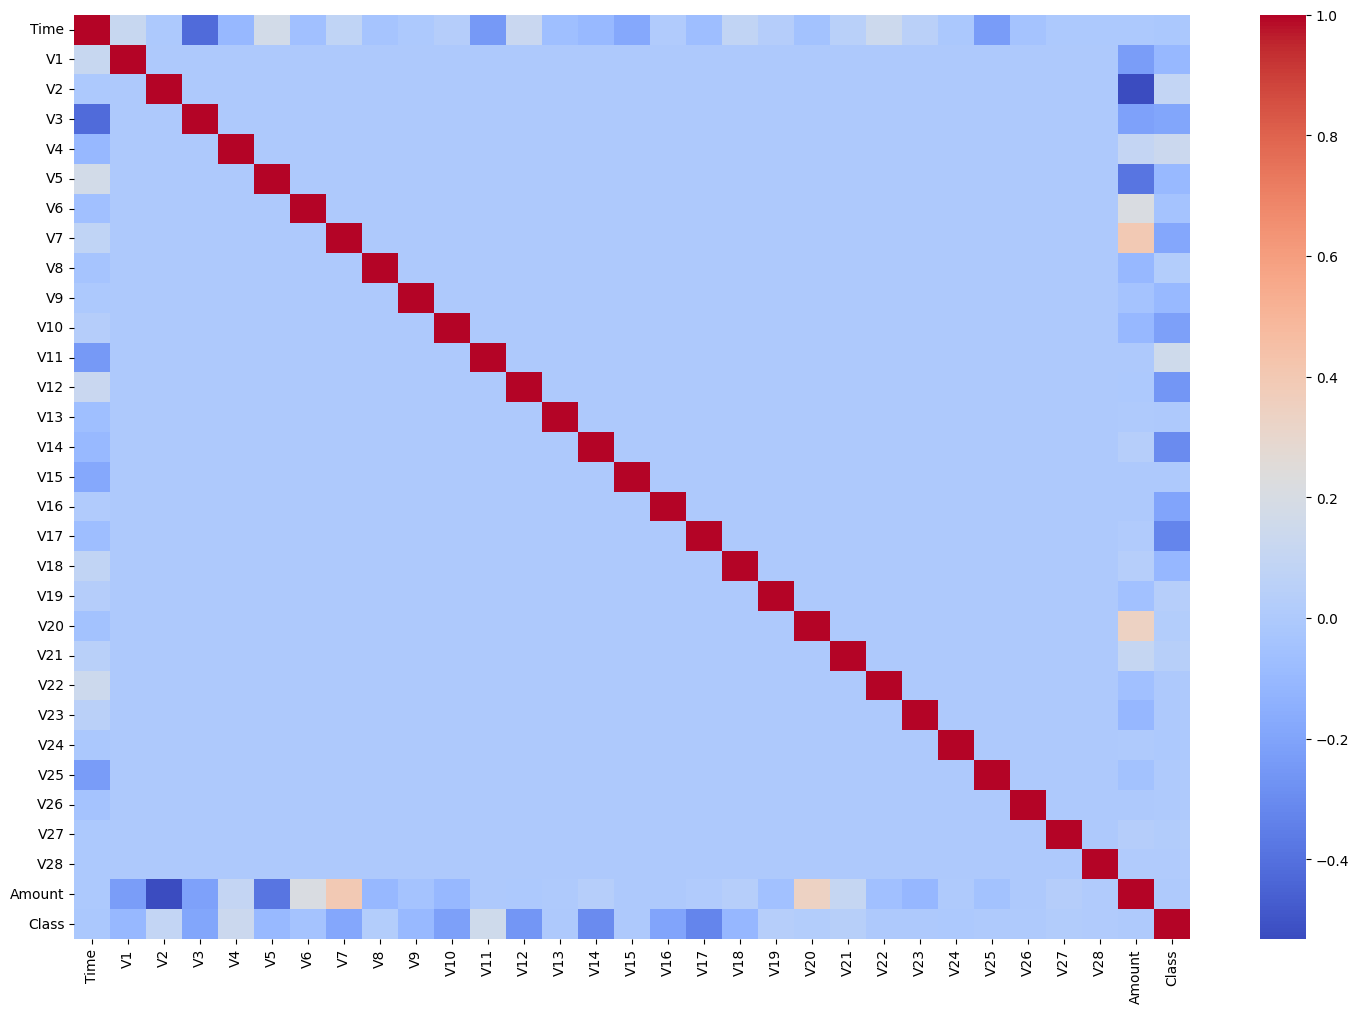

In [13]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.show()

In [14]:
X = df.drop('Class', axis=1)

y = df['Class']

In [15]:
scaler = StandardScaler()

X[['Amount','Time']] = scaler.fit_transform(
    X[['Amount','Time']]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9991573329588147


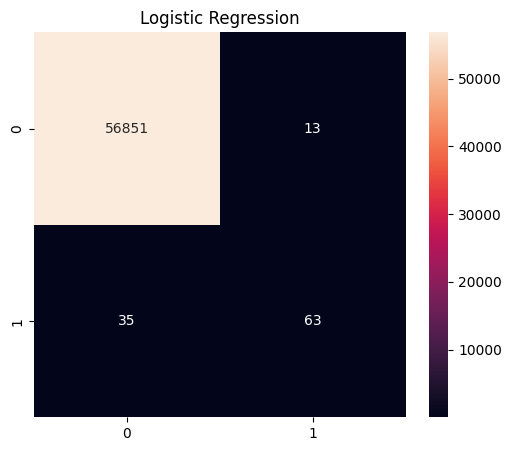

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression"
)

plt.show()

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [21]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9995962220427653


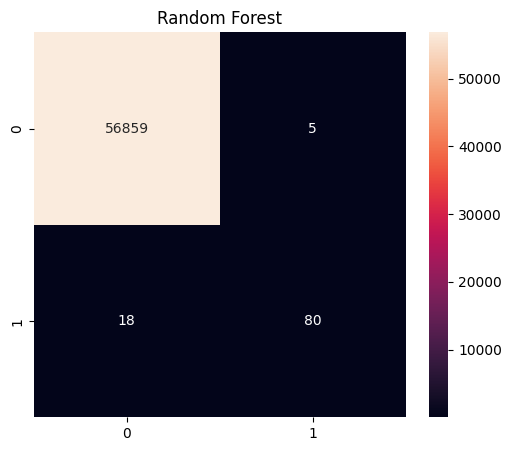

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Random Forest"
)

plt.show()

In [23]:
y_prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9630272515590367


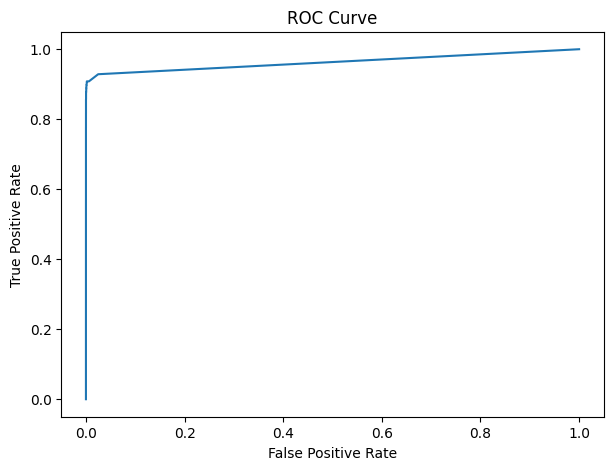

In [24]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [25]:
lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.999157
1,Random Forest,0.999596


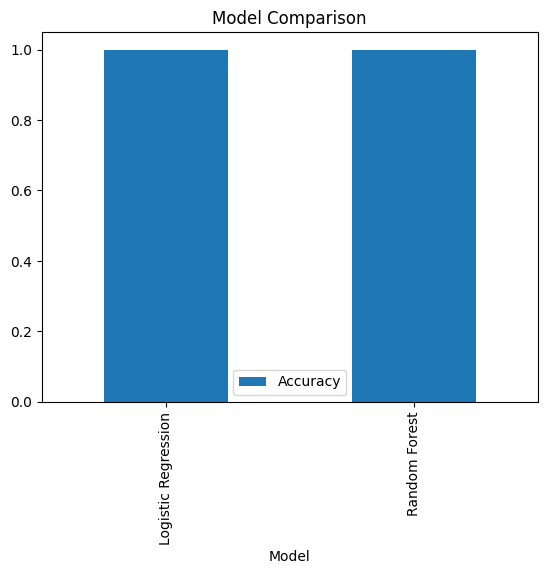

In [26]:
comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title(
    "Model Comparison"
)

plt.show()